# Notebook 06 — Two-Digit MNIST

This notebook extends single-digit classification to an image that contains **two**
stacked MNIST digits. The important change is not the image size, but the **target
structure**: instead of predicting one of ten digits, the model must predict two
digits simultaneously.

```text
             image
               |
               v
        shared representation
             /     \
            /       \
           v         v
      digit 1      digit 2
       output       output
```

We build a fully connected model and a CNN, each with **two output heads** sharing one
internal representation, and compare them.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import torch

from two_digit.data_utils import get_two_digit_data, IMG_ROWS, IMG_COLS
from two_digit.train_utils import batchify_data, train_model, run_epoch, exact_match_accuracy
from two_digit.mlp import MLP
from two_digit.conv import CNN

np.random.seed(12321)
torch.manual_seed(12321)

## 1. Inspect the two-digit images

Each image is $42\times28$: two $28\times28$ MNIST digits stacked vertically.

X_train: (5000, 1, 42, 28)
first-digit labels: (5000,)  second-digit labels: (5000,)
X_test:  (1000, 1, 42, 28)


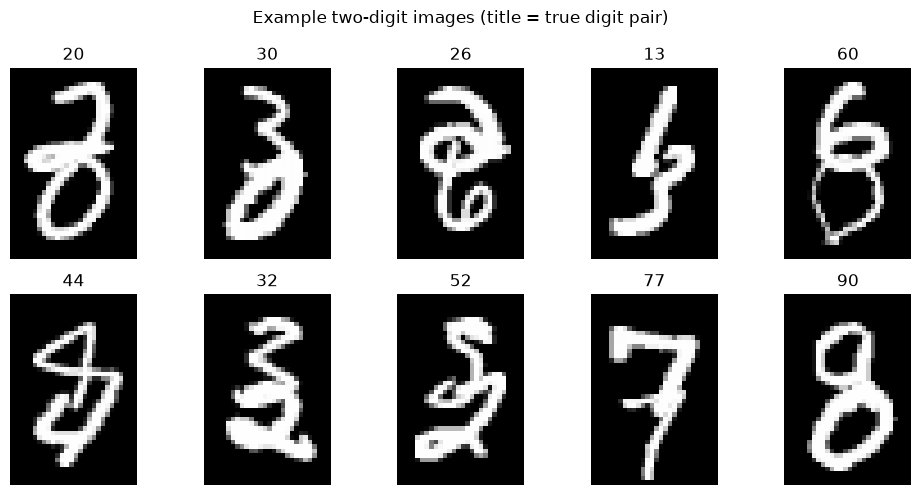

In [2]:
X_train, y_train, X_test, y_test = get_two_digit_data(use_mini_dataset=True)

print("X_train:", X_train.shape)
print("first-digit labels:", y_train[0].shape, " second-digit labels:", y_train[1].shape)
print("X_test: ", X_test.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, 0], cmap="Greys_r")
    ax.set_title(f"{y_train[0][i]}{y_train[1][i]}")
    ax.axis("off")
plt.suptitle("Example two-digit images (title = true digit pair)")
plt.tight_layout()
plt.show()

## 2. The two labels

`y_train` is a list of two label arrays: `y_train[0]` is the digit shown in the top
half of the image, `y_train[1]` is the digit shown in the bottom half. Every image has
exactly one label pair.

In [3]:
print("first five (digit1, digit2) pairs:")
for d1, d2 in list(zip(y_train[0][:5], y_train[1][:5])):
    print(f"  ({d1}, {d2})")

first five (digit1, digit2) pairs:
  (2, 0)
  (3, 0)
  (2, 6)
  (1, 3)
  (6, 0)


## 3-4. Why two output heads

A single ten-class output can only represent one categorical choice among ten
options. Here each image encodes **two independent** digit labels (100 possible
pairs, not 10), so the model needs two separate ten-way classification heads, one per
digit position, rather than a single output layer.

Both heads share the same underlying representation of the image (the same
convolutional/fully-connected trunk), which reflects the idea that recognizing "what
digit is drawn here" is fundamentally the same sub-problem whether it appears in the
top half or the bottom half of the image.

## 5. Combined loss

Each head produces its own cross-entropy loss against its own labels; the network is
trained to minimize the sum

$$
L = L_1 + L_2,
$$

where $L_1$ is the cross-entropy loss for the first digit and $L_2$ for the second.
Both heads are trained jointly through this combined loss.

## 6. Train and evaluate the MLP

In [4]:
dev_split_index = int(9 * len(X_train) / 10)
permutation = np.random.permutation(len(X_train))
X_train_shuf = X_train[permutation]
y_train_shuf = [y_train[0][permutation], y_train[1][permutation]]

X_dev = X_train_shuf[dev_split_index:]
y_dev = [y_train_shuf[0][dev_split_index:], y_train_shuf[1][dev_split_index:]]
X_tr = X_train_shuf[:dev_split_index]
y_tr = [y_train_shuf[0][:dev_split_index], y_train_shuf[1][:dev_split_index]]

batch_size = 64
mlp_train_batches = batchify_data(X_tr, y_tr, batch_size)
mlp_dev_batches = batchify_data(X_dev, y_dev, batch_size)
mlp_test_batches = batchify_data(X_test, y_test, batch_size)

mlp_model = MLP(input_dimension=IMG_ROWS * IMG_COLS, hidden_dim=128, num_classes=10)
mlp_history = train_model(
    mlp_train_batches, mlp_dev_batches, mlp_model, lr=0.1, momentum=0.9, n_epochs=8
)

Epoch  1 | train loss1 1.1692 loss2 1.1217 acc1 0.6204 acc2 0.6413 | val loss1 0.5712 loss2 0.7617 acc1 0.8275 acc2 0.7578
Epoch  2 | train loss1 0.5424 loss2 0.5738 acc1 0.8286 acc2 0.8115 | val loss1 0.5349 loss2 0.5926 acc1 0.8364 acc2 0.8197
Epoch  3 | train loss1 0.3732 loss2 0.4037 acc1 0.8800 acc2 0.8651 | val loss1 0.6134 loss2 0.5545 acc1 0.8193 acc2 0.8245
Epoch  4 | train loss1 0.3037 loss2 0.2990 acc1 0.8968 acc2 0.9016 | val loss1 0.4858 loss2 0.6157 acc1 0.8534 acc2 0.8078
Epoch  5 | train loss1 0.2585 loss2 0.2558 acc1 0.9135 acc2 0.9121 | val loss1 0.4997 loss2 0.6062 acc1 0.8597 acc2 0.8419
Epoch  6 | train loss1 0.2142 loss2 0.2220 acc1 0.9265 acc2 0.9236 | val loss1 0.5673 loss2 0.6725 acc1 0.8460 acc2 0.8280
Epoch  7 | train loss1 0.1910 loss2 0.1842 acc1 0.9355 acc2 0.9395 | val loss1 0.6370 loss2 0.5036 acc1 0.8308 acc2 0.8571
Epoch  8 | train loss1 0.1784 loss2 0.1636 acc1 0.9379 acc2 0.9416 | val loss1 0.4879 loss2 0.5717 acc1 0.8577 acc2 0.8508


In [5]:
mlp_model.eval()
with torch.no_grad():
    mlp_test_loss, mlp_test_acc = run_epoch(mlp_test_batches, mlp_model, None)
mlp_exact_match = exact_match_accuracy(mlp_model, mlp_test_batches)

print(f"MLP test loss:  digit1 {mlp_test_loss[0]:.4f}  digit2 {mlp_test_loss[1]:.4f}")
print(f"MLP test acc:   digit1 {mlp_test_acc[0]:.4f}  digit2 {mlp_test_acc[1]:.4f}")
print(f"MLP exact-match accuracy (both digits correct): {mlp_exact_match:.4f}")

MLP test loss:  digit1 0.6123  digit2 0.5877
MLP test acc:   digit1 0.8357  digit2 0.8480
MLP exact-match accuracy (both digits correct): 0.7050


## 7-8. Define and train the CNN version

In [6]:
cnn_train_batches = batchify_data(X_tr, y_tr, batch_size)
cnn_dev_batches = batchify_data(X_dev, y_dev, batch_size)
cnn_test_batches = batchify_data(X_test, y_test, batch_size)

cnn_model = CNN()
cnn_history = train_model(
    cnn_train_batches, cnn_dev_batches, cnn_model, lr=0.1, momentum=0.9, nesterov=True, n_epochs=8
)

Epoch  1 | train loss1 1.6977 loss2 1.7150 acc1 0.3979 acc2 0.3731 | val loss1 0.5947 loss2 1.0164 acc1 0.8060 acc2 0.6651
Epoch  2 | train loss1 0.3741 loss2 0.4394 acc1 0.8780 acc2 0.8413 | val loss1 0.3268 loss2 0.4002 acc1 0.8963 acc2 0.8645
Epoch  3 | train loss1 0.2055 loss2 0.2373 acc1 0.9306 acc2 0.9170 | val loss1 0.2746 loss2 0.3706 acc1 0.9020 acc2 0.8903
Epoch  4 | train loss1 0.1422 loss2 0.1464 acc1 0.9551 acc2 0.9496 | val loss1 0.2884 loss2 0.4526 acc1 0.9318 acc2 0.8884
Epoch  5 | train loss1 0.1061 loss2 0.1202 acc1 0.9654 acc2 0.9584 | val loss1 0.3667 loss2 0.3947 acc1 0.9079 acc2 0.9088
Epoch  6 | train loss1 0.0739 loss2 0.1073 acc1 0.9729 acc2 0.9602 | val loss1 0.2953 loss2 0.3771 acc1 0.9235 acc2 0.9118
Epoch  7 | train loss1 0.0738 loss2 0.1039 acc1 0.9747 acc2 0.9652 | val loss1 0.3402 loss2 0.5340 acc1 0.9148 acc2 0.8996
Epoch  8 | train loss1 0.0540 loss2 0.0759 acc1 0.9809 acc2 0.9723 | val loss1 0.4246 loss2 0.4486 acc1 0.9099 acc2 0.9133


In [7]:
cnn_model.eval()
with torch.no_grad():
    cnn_test_loss, cnn_test_acc = run_epoch(cnn_test_batches, cnn_model, None)
cnn_exact_match = exact_match_accuracy(cnn_model, cnn_test_batches)

print(f"CNN test loss:  digit1 {cnn_test_loss[0]:.4f}  digit2 {cnn_test_loss[1]:.4f}")
print(f"CNN test acc:   digit1 {cnn_test_acc[0]:.4f}  digit2 {cnn_test_acc[1]:.4f}")
print(f"CNN exact-match accuracy (both digits correct): {cnn_exact_match:.4f}")

CNN test loss:  digit1 0.3836  digit2 0.3956
CNN test acc:   digit1 0.9170  digit2 0.9057
CNN exact-match accuracy (both digits correct): 0.8340


## 9-10. Per-digit and exact-match accuracy

In [8]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "model": ["MLP", "CNN"],
        "digit1 accuracy": [mlp_test_acc[0], cnn_test_acc[0]],
        "digit2 accuracy": [mlp_test_acc[1], cnn_test_acc[1]],
        "exact-match accuracy": [mlp_exact_match, cnn_exact_match],
    }
)
comparison

,model,digit1 accuracy,digit2 accuracy,exact-match accuracy
0,MLP,0.835742,0.848047,0.705
1,CNN,0.916992,0.905664,0.834


## 11. Compare MLP and CNN

Note that exact-match accuracy is necessarily less than or equal to either per-digit
accuracy: both digits must be correct simultaneously. As in Notebook 05, the CNN's
convolutional trunk gives it access to the 2-D spatial layout of the stacked digits —
including the vertical relationship between the top and bottom halves of the image —
which the flattened MLP input does not preserve.

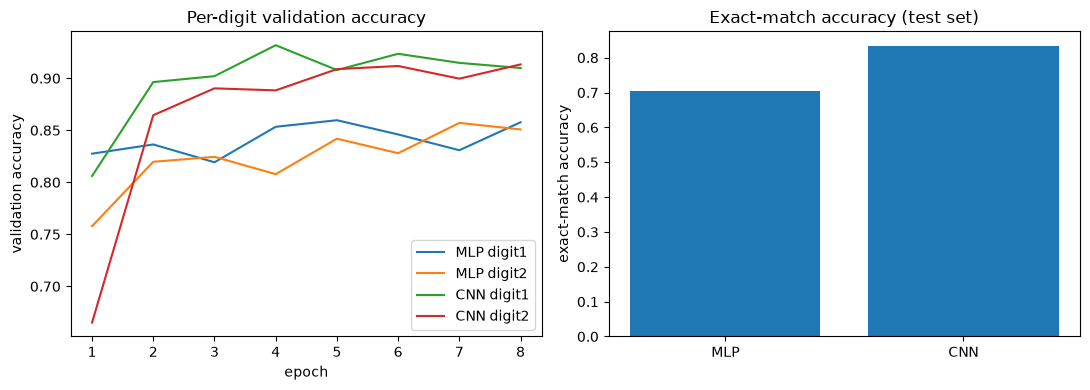

In [9]:
epochs = range(1, len(mlp_history["val_acc"]) + 1)
mlp_val_acc1 = [a[0] for a in mlp_history["val_acc"]]
mlp_val_acc2 = [a[1] for a in mlp_history["val_acc"]]
cnn_val_acc1 = [a[0] for a in cnn_history["val_acc"]]
cnn_val_acc2 = [a[1] for a in cnn_history["val_acc"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, mlp_val_acc1, label="MLP digit1")
axes[0].plot(epochs, mlp_val_acc2, label="MLP digit2")
axes[0].plot(epochs, cnn_val_acc1, label="CNN digit1")
axes[0].plot(epochs, cnn_val_acc2, label="CNN digit2")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation accuracy")
axes[0].set_title("Per-digit validation accuracy")
axes[0].legend()

axes[1].bar(
    ["MLP", "CNN"],
    [mlp_exact_match, cnn_exact_match],
)
axes[1].set_ylabel("exact-match accuracy")
axes[1].set_title("Exact-match accuracy (test set)")
plt.tight_layout()
plt.show()

### A few predictions

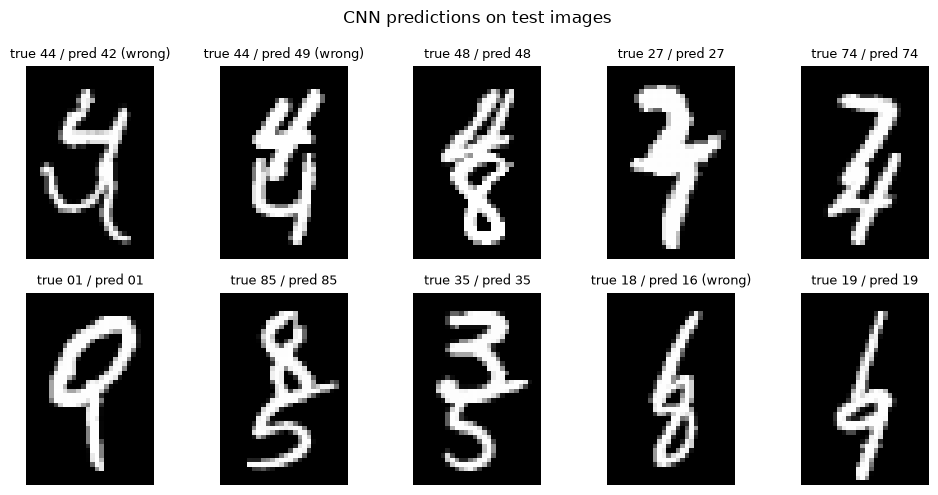

In [10]:
cnn_model.eval()
with torch.no_grad():
    sample_x = torch.tensor(X_test[:10], dtype=torch.float32)
    out1, out2 = cnn_model(sample_x)
    pred1 = torch.argmax(out1, dim=1).numpy()
    pred2 = torch.argmax(out2, dim=1).numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i, 0], cmap="Greys_r")
    true_pair = f"{y_test[0][i]}{y_test[1][i]}"
    pred_pair = f"{pred1[i]}{pred2[i]}"
    mark = "" if true_pair == pred_pair else " (wrong)"
    ax.set_title(f"true {true_pair} / pred {pred_pair}{mark}", fontsize=9)
    ax.axis("off")
plt.suptitle("CNN predictions on test images")
plt.tight_layout()
plt.show()

## Study questions

1. Why is one ordinary ten-class output insufficient for two independent digit
   labels?
2. What parameters are shared between the two output heads?
3. Why might the CNN benefit from the spatial structure of the two digits?